# Week 10 Lab — Practical Deep Learning: Augmentation, Dropout & Batch Normalization (Student)

**Instructions**: fill in every `___` blank and implement every `# TODO` comment.  
Do *not* look at the solutions notebook until you have tried each step yourself!

Run cells in order — each step depends on variables set in the previous one.

---

**What you will build:**
- A cats-vs-dogs binary classifier using CIFAR-10
- Observe overfitting on a baseline model
- Fix it with data augmentation, Dropout, and Batch Normalization
- Compare training curves across all four models

---
# Part 1 — Setup and Data Loading

We will use CIFAR-10 and extract only **cats** (class 3) and **dogs** (class 5) to create a binary classification problem.

## Step 1 — Imports

Import all the libraries you need for this lab.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical



## Step 2 — Load CIFAR-10 and Extract Cats & Dogs

In [2]:
# Load CIFAR-10
(x_train_all, y_train_all), (x_test_all, y_test_all) = cifar10.load_data()

# CIFAR-10 class indices:
# 0=airplane, 1=automobile, 2=bird, 3=cat, 4=deer,
# 5=dog, 6=frog, 7=horse, 8=ship, 9=truck
CAT_LABEL = 3
DOG_LABEL = 5

# TODO: extract training samples where label is CAT or DOG
# Hint: use np.where() or boolean indexing on y_train_all.flatten()
train_mask = np.isin(y_train_all.flatten(), [CAT_LABEL, DOG_LABEL])
x_train = x_train_all[train_mask]
y_train_raw = y_train_all[train_mask].flatten()

# TODO: do the same for the test set
test_mask = np.isin(y_test_all.flatten(), [CAT_LABEL, DOG_LABEL])
x_test = x_test_all[test_mask]
y_test_raw = y_test_all[test_mask].flatten()

# Convert labels to binary: cat=0, dog=1
y_train = (y_train_raw == DOG_LABEL).astype('float32')
y_test  = (y_test_raw  == DOG_LABEL).astype('float32')

print("Training set:", x_train.shape, "| Labels:", y_train.shape)
print("Test set:    ", x_test.shape,  "| Labels:", y_test.shape)
print(f"Cats in train: {np.sum(y_train==0)}, Dogs in train: {np.sum(y_train==1)}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Training set: (10000, 32, 32, 3) | Labels: (10000,)
Test set:     (2000, 32, 32, 3) | Labels: (2000,)
Cats in train: 5000, Dogs in train: 5000


## Step 3 — Normalize Pixel Values and Visualize

In [3]:
# TODO: normalize x_train and x_test to the range [0, 1]
# Hint: pixel values are integers in [0, 255]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

print("Pixel range — min:", x_train.min(), "max:", x_train.max())

Pixel range — min: 0.0 max: 1.0


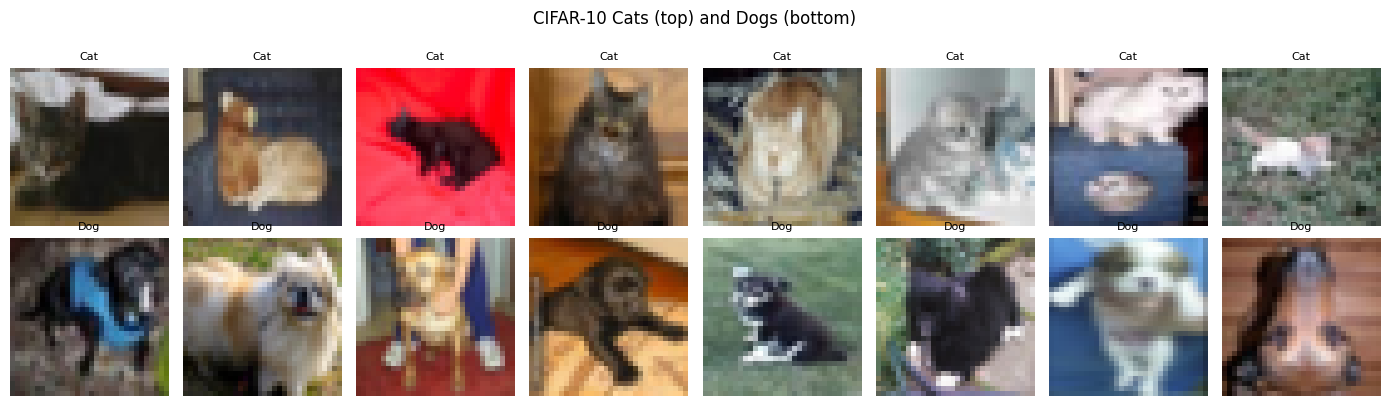

In [4]:
# Visualize some training images
class_names = ['Cat', 'Dog']
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for row, label in enumerate([0, 1]):
    imgs = x_train[y_train == label][:8]
    for col, img in enumerate(imgs):
        axes[row, col].imshow(img)
        axes[row, col].set_title(class_names[label], fontsize=8)
        axes[row, col].axis('off')
plt.suptitle('CIFAR-10 Cats (top) and Dogs (bottom)', y=1.01)
plt.tight_layout()
plt.show()

---
# Part 2 — Baseline CNN (No Augmentation, No Regularization)

We'll build a simple CNN and intentionally let it overfit, so we can see what the problem looks like.

## Step 4 — Build the Baseline CNN

Build a `Sequential` model with this architecture:
1. `Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3))`
2. `MaxPooling2D(2,2)`
3. `Conv2D(64, (3,3), activation='relu')`
4. `MaxPooling2D(2,2)`
5. `Flatten()`
6. `Dense(128, activation='relu')`
7. `Dense(1, activation='sigmoid')` — binary output

In [6]:
def build_baseline_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

c:\Users\jcahi\OneDrive\Desktop\musa-650-spring2026\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,561 (1.20 MB)

 Trainable params: 314,561 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

## Step 5 — Compile and Train the Baseline Model

In [7]:
# TODO: compile the model
# Use: optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']
baseline_model.compile(    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# TODO: train the model for 20 epochs, batch_size=64
# Use validation_data=(x_test, y_test)
# Store the result in a variable called `history_baseline`
history_baseline = baseline_model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=20,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5650 - loss: 0.6746 - val_accuracy: 0.6440 - val_loss: 0.6367
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6660 - loss: 0.6107 - val_accuracy: 0.6840 - val_loss: 0.5933
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7045 - loss: 0.5632 - val_accuracy: 0.6870 - val_loss: 0.5846
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7326 - loss: 0.5346 - val_accuracy: 0.7095 - val_loss: 0.5535
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7462 - loss: 0.5075 - val_accuracy: 0.7335 - val_loss: 0.5195
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7690 - loss: 0.4764 - val_accuracy: 0.7135 - val_loss: 0.5534
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7844 - loss: 0.4535 - val_accuracy: 0.7500 - val_loss: 0.5179
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7997 - loss: 0.4224 - val_accu

## Step 6 — Plot Training Curves and Observe Overfitting

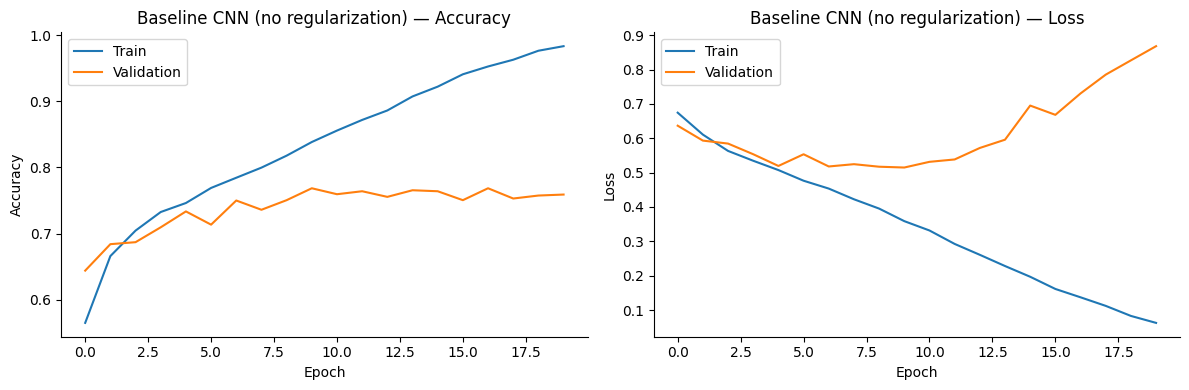

In [8]:
def plot_history(history, title='Training Curves'):
    """Plot training and validation accuracy and loss."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(title + ' — Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)
    
    # Loss
    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(title + ' — Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

plot_history(history_baseline, 'Baseline CNN (no regularization)')

**Question**: Do you see overfitting? What is the gap between training and validation accuracy at the end of training? Write your answer in the cell below.

*Your answer here:*

---
# Part 3 — Data Augmentation

Now we'll add data augmentation using `ImageDataGenerator` and retrain the *same* baseline architecture to see if it helps.

## Step 7 — Visualize Augmented Cat Images

Before training, let's see what augmented images look like.

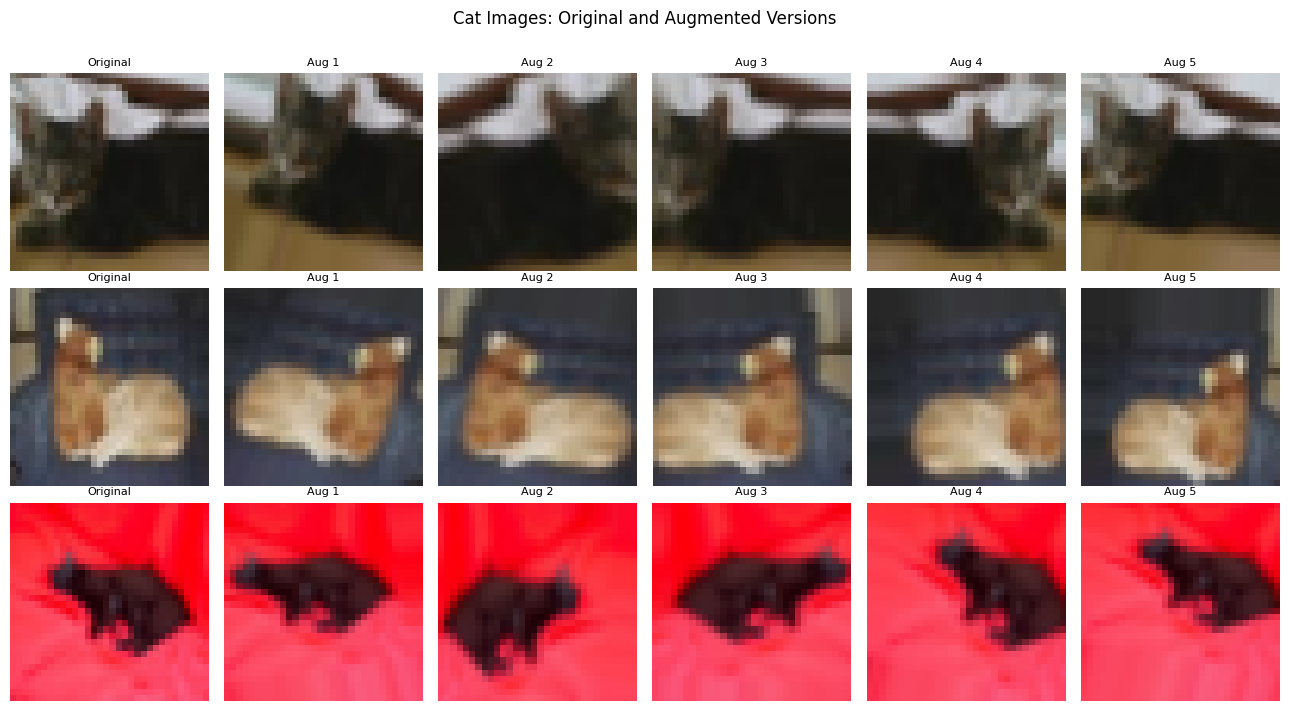

In [9]:
# TODO: create an ImageDataGenerator with these settings:
#   rotation_range=20
#   width_shift_range=0.15
#   height_shift_range=0.15
#   horizontal_flip=True
#   zoom_range=0.2
#   fill_mode='nearest'
aug_datagen = ImageDataGenerator(    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest')

# Visualize augmented versions of 3 cat images
cat_images = x_train[y_train == 0][:3]  # 3 cat images (already normalized)

fig, axes = plt.subplots(3, 6, figsize=(13, 7))
for row, cat in enumerate(cat_images):
    axes[row, 0].imshow(cat)
    axes[row, 0].set_title('Original', fontsize=8)
    axes[row, 0].axis('off')
    img_batch = cat.reshape((1,) + cat.shape)
    for col, batch in zip(range(1, 6), aug_datagen.flow(img_batch, batch_size=1)):
        axes[row, col].imshow(np.clip(batch[0], 0, 1))
        axes[row, col].set_title(f'Aug {col}', fontsize=8)
        axes[row, col].axis('off')
plt.suptitle('Cat Images: Original and Augmented Versions', y=1.01)
plt.tight_layout()
plt.show()

## Step 8 — Train the Same Model with Augmentation

In [10]:
# Build a fresh copy of the baseline model (no regularization)
aug_model = build_baseline_model()
aug_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# TODO: create a generator using aug_datagen.flow()
# Use x_train, y_train, batch_size=64
train_gen = aug_datagen.flow(aug_datagen.flow(x_train, y_train, batch_size=64))

# TODO: train aug_model using train_gen for 20 epochs
# Set steps_per_epoch = len(x_train) // 64
# Use validation_data=(x_test, y_test)
# Store result in history_aug
history_aug = aug_model.fit(
    train_gen,
    steps_per_epoch=len(x_train) // 64,
    epochs=20,
    validation_data=(x_test, y_test),
    verbose=1
)

plot_history(history_aug, 'CNN with Data Augmentation')

MemoryError: Unable to allocate 768. KiB for an array with shape (64, 32, 32, 3) and data type float32

**Question**: Compare this to the baseline. Did augmentation reduce the train/validation gap? Write your answer below.

*Your answer here:*

---
# Part 4 — Adding Dropout

Now rebuild the model adding `Dropout` layers.

## Step 9 — Build a Model with Dropout

Same architecture as baseline, but add:
- `Dropout(0.25)` after the second `MaxPooling2D`
- `Dropout(0.5)` after the `Dense(128)` layer

In [ ]:
def build_dropout_model():
    model = Sequential()
    # TODO: build the model with Dropout layers added at the positions described above
    # Architecture:
    # Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3))
    # MaxPooling2D(2,2)
    # Conv2D(64, (3,3), activation='relu')
    # MaxPooling2D(2,2)
    # Dropout(0.25)          <-- add here
    # Flatten()
    # Dense(128, activation='relu')
    # Dropout(0.5)           <-- add here
    # Dense(1, activation='sigmoid')
    
    return model

dropout_model = build_dropout_model()
dropout_model.summary()

## Step 10 — Train with Augmentation + Dropout

In [ ]:
# TODO: compile the dropout_model (same settings as before)
dropout_model.compile(___)

# TODO: train with augmentation for 20 epochs (use aug_datagen.flow again)
# Store result in history_dropout
train_gen2 = aug_datagen.flow(x_train, y_train, batch_size=64)
history_dropout = dropout_model.fit(
    ___
)

plot_history(history_dropout, 'CNN with Augmentation + Dropout')

---
# Part 5 — Adding Batch Normalization

Now build a model with `BatchNormalization` added after each convolutional layer.

## Step 11 — Build a Model with Batch Normalization + Dropout

Architecture:
1. `Conv2D(32, (3,3), input_shape=(32,32,3))` — no activation yet
2. `BatchNormalization()`
3. `Activation('relu')`
4. `MaxPooling2D(2,2)`
5. `Conv2D(64, (3,3))` — no activation yet
6. `BatchNormalization()`
7. `Activation('relu')`
8. `MaxPooling2D(2,2)`
9. `Dropout(0.25)`
10. `Flatten()`
11. `Dense(128)` — no activation yet
12. `BatchNormalization()`
13. `Activation('relu')`
14. `Dropout(0.5)`
15. `Dense(1, activation='sigmoid')`

In [ ]:
def build_bn_model():
    model = Sequential()
    # TODO: build the full model with BatchNormalization + Dropout as described above
    
    return model

bn_model = build_bn_model()
bn_model.summary()

## Step 12 — Train with Augmentation + BatchNorm + Dropout

In [ ]:
# TODO: compile and train the bn_model for 20 epochs with augmentation
# Store result in history_bn
bn_model.compile(___)

train_gen3 = aug_datagen.flow(x_train, y_train, batch_size=64)
history_bn = bn_model.fit(
    ___
)

plot_history(history_bn, 'CNN with Augmentation + BatchNorm + Dropout')

---
# Part 6 — Compare All Models

## Step 13 — Side-by-Side Validation Accuracy Comparison

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(history_baseline.history['val_accuracy'], label='Baseline',              linestyle='--')
ax.plot(history_aug.history['val_accuracy'],      label='+ Augmentation',        linestyle='-')
ax.plot(history_dropout.history['val_accuracy'],  label='+ Augmentation+Dropout',linestyle='-.')
ax.plot(history_bn.history['val_accuracy'],       label='+ Aug+BN+Dropout',      linestyle=':')

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Validation Accuracy: All Four Models')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Print final test accuracies
print("Final validation accuracies (last epoch):")
print(f"  Baseline:               {history_baseline.history['val_accuracy'][-1]:.3f}")
print(f"  + Augmentation:         {history_aug.history['val_accuracy'][-1]:.3f}")
print(f"  + Aug + Dropout:        {history_dropout.history['val_accuracy'][-1]:.3f}")
print(f"  + Aug + BN + Dropout:   {history_bn.history['val_accuracy'][-1]:.3f}")

---
# Part 7 — Reflection

Answer the following questions in new markdown cells:

1. Looking at the training curves, which model shows the most overfitting? What is the sign of overfitting?

2. Did augmentation alone help? By how much did the train/val accuracy gap change?

3. What effect did Dropout have on the training accuracy vs. validation accuracy?

4. Batch Normalization is often said to speed up training. Do you observe faster convergence (reaching a good accuracy in fewer epochs) in the BN model?

5. Which model would you deploy? Why?

6. **Bonus**: Modify the best model to classify all 10 CIFAR-10 classes instead of just cats vs dogs. What needs to change in the output layer and loss function?

*Your answers here:*